# **Simple Perceptron (Single Sample)**

### Step 1: initialize
`w1 = 0.5` <br>
`w2 = -0.5`<br>
`b = 0.1`<br>
`lr = 0.1`   # learning rate

### input and target
`x1 = 1` <br>
`x2 = 0` <br>
`y = 1      # true label`

### Step 2: weighted sum
`z = w1*x1 + w2*x2 + b`

### Step 3: activation
`y_pred = 1 if z >= 0 else 0`

### Step 4: error
`error = y - y_pred`

### Step 5: weight update
`w1 = w1 + lr * error * x1` <br>
`w2 = w2 + lr * error * x2`

### Step 6: bias update
`b = b + lr * error`

### output
`w1, w2, b`

#**Implementation of Perceptron**

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
plt.style.use("fivethirtyeight")

In [151]:
class Perceptron:
  def __init__(self, eta, epochs):
    self.weights = np.random.randn(3) * 1e-4
    print("Weights ", self.weights)
    self.eta = eta
    self.epochs = epochs

  def activation_function(self, inputs, weights):
    z = np.dot(inputs, weights)
    return np.where(z > 0, 1, 0)

  def fit(self, X, y):
    self.X = X
    self.y = y
    bias = -np.ones((len(X), 1))

    X = np.c_[X, bias]
    print("Final X befor predict ", X)
    for epoch in range(self.epochs):
      print(f"\n######### Epoch: {epoch + 1} ############\n")

      y_hat = self.activation_function(X, self.weights)
      print("Y hat ", y_hat)

      errors = y - y_hat
      print("Errors: ", errors)

      # weight update
      # new weights = old weights + eta * errors * x
      self.weights = self.weights + self.eta * np.dot(X.T, errors)
      print("New Weights\n", self.weights)

  def predict(self, X):
    bias = -np.ones((len(X), 1))
    X = np.c_[X, bias]
    return self.activation_function(X, self.weights)

In [152]:
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,0,0,1]}

AND = pd.DataFrame(data)
AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [153]:
X = AND.drop(columns=['y'])
y = AND['y']
y.to_frame()

,y
0,0
1,0
2,0
3,1


In [154]:
model = Perceptron(eta = 0.5, epochs=10)
model.fit(X,y)

Weights  [ 5.27176692e-05 -5.11190702e-06 -1.10838636e-05]
Final X befor predict  [[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]

######### Epoch: 1 ############

Y hat  [1 1 1 1]
Errors:  0   -1
1   -1
2   -1
3    0
Name: y, dtype: int64
New Weights
 [-0.49994728 -0.50000511  1.49998892]

######### Epoch: 2 ############

Y hat  [0 0 0 0]
Errors:  0    0
1    0
2    0
3    1
Name: y, dtype: int64
New Weights
 [ 5.27176692e-05 -5.11190702e-06  9.99988916e-01]

######### Epoch: 3 ############

Y hat  [0 0 0 0]
Errors:  0    0
1    0
2    0
3    1
Name: y, dtype: int64
New Weights
 [0.50005272 0.49999489 0.49998892]

######### Epoch: 4 ############

Y hat  [0 1 1 1]
Errors:  0    0
1   -1
2   -1
3    0
Name: y, dtype: int64
New Weights
 [ 5.27176692e-05 -5.11190702e-06  1.49998892e+00]

######### Epoch: 5 ############

Y hat  [0 0 0 0]
Errors:  0    0
1    0
2    0
3    1
Name: y, dtype: int64
New Weights
 [0.50005272 0.49999489 0.99998892]

######### Epoch: 6 ############



In [155]:
model.predict(np.array([[1, 1]]))

array([1])

In [156]:
import os

# saving model
dir_ = "Perceptron_model"
os.makedirs(dir_, exist_ok=True)
filename = os.path.join(dir_, 'AND_model.model')
joblib.dump(model, filename)

['Perceptron_model/AND_model.model']

In [166]:
# load the model from drive
loaded_model = joblib.load(filename)
result = loaded_model.predict(X)
print(result)

[0 0 0 1]


## **OR operations**

In [158]:
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,1,1,1]}

OR = pd.DataFrame(data)
OR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [159]:
X = OR.drop(columns=['y'])
y = OR['y']
y.to_frame()

,y
0,0
1,1
2,1
3,1


In [160]:
model = Perceptron(eta = 0.5, epochs=10)
model.fit(X,y)

Weights  [-9.84379573e-05  1.12539499e-04  2.83442990e-05]
Final X befor predict  [[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]

######### Epoch: 1 ############

Y hat  [0 1 0 0]
Errors:  0    0
1    0
2    1
3    1
Name: y, dtype: int64
New Weights
 [ 0.99990156  0.50011254 -0.99997166]

######### Epoch: 2 ############

Y hat  [1 1 1 1]
Errors:  0   -1
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [ 0.99990156  0.50011254 -0.49997166]

######### Epoch: 3 ############

Y hat  [1 1 1 1]
Errors:  0   -1
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [9.99901562e-01 5.00112539e-01 2.83442990e-05]

######### Epoch: 4 ############

Y hat  [0 1 1 1]
Errors:  0    0
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [9.99901562e-01 5.00112539e-01 2.83442990e-05]

######### Epoch: 5 ############

Y hat  [0 1 1 1]
Errors:  0    0
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [9.99901562e-01 5.00112539e-01 2.83442990e-05]

######### Epoch: 6 #####

**XOR**

In [161]:
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,1,1,0]}

XOR = pd.DataFrame(data)
XOR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [162]:
X = OR.drop(columns=['y'])
y = OR['y']
y.to_frame()

,y
0,0
1,1
2,1
3,1


In [163]:
model = Perceptron(eta = 0.5, epochs=10)
model.fit(X,y)

Weights  [ 7.18697116e-05 -1.29550727e-04  3.19358155e-05]
Final X befor predict  [[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]

######### Epoch: 1 ############

Y hat  [0 0 1 0]
Errors:  0    0
1    1
2    0
3    1
Name: y, dtype: int64
New Weights
 [ 0.50007187  0.99987045 -0.99996806]

######### Epoch: 2 ############

Y hat  [1 1 1 1]
Errors:  0   -1
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [ 0.50007187  0.99987045 -0.49996806]

######### Epoch: 3 ############

Y hat  [1 1 1 1]
Errors:  0   -1
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [5.00071870e-01 9.99870449e-01 3.19358155e-05]

######### Epoch: 4 ############

Y hat  [0 1 1 1]
Errors:  0    0
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [5.00071870e-01 9.99870449e-01 3.19358155e-05]

######### Epoch: 5 ############

Y hat  [0 1 1 1]
Errors:  0    0
1    0
2    0
3    0
Name: y, dtype: int64
New Weights
 [5.00071870e-01 9.99870449e-01 3.19358155e-05]

######### Epoch: 6 #####

In [164]:
def graph_analysis(df, title):
    df.plot(kind="scatter", x="x1", y="x2", c="y", s=50, cmap="winter")
    plt.title(title)

    plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
    plt.axvline(x=0, color="black", linestyle="--", linewidth=2)

    x = np.linspace(0, 1.4, 50)
    y = 1.5 - x

    plt.plot(x, y, "r--")

None

None

None

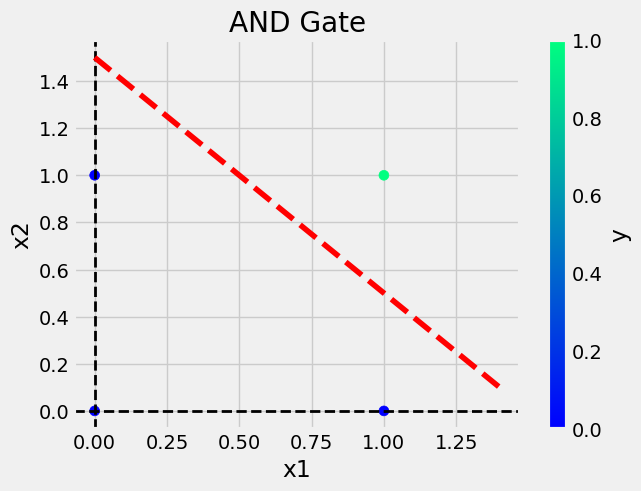

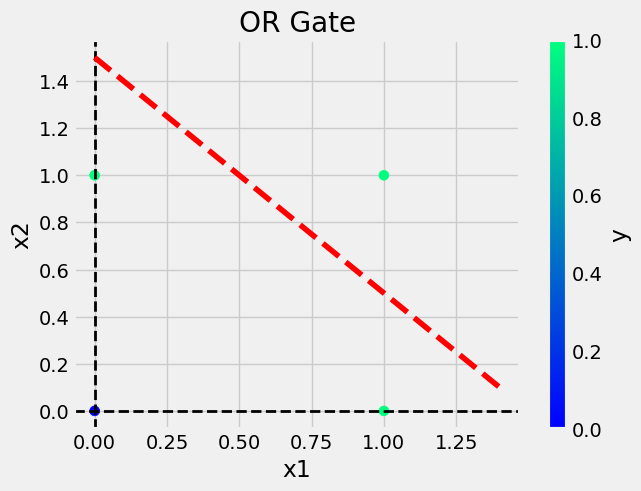

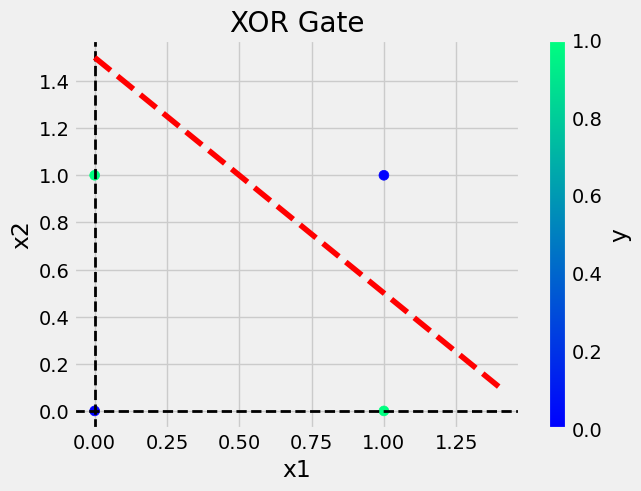

In [165]:
display(graph_analysis(AND, "AND Gate"))
display(graph_analysis(OR, "OR Gate"))
display(graph_analysis(XOR, "XOR Gate"))


Why Xor is fail? <br>
_we see in AND, OR we can linearly separable classes but for XOR we can see that it's not possible._